<a href="https://colab.research.google.com/github/redinbluesky/nlp-with-transformers/blob/main/08-효율적인_트랜스포머_구축.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  목차
* [Chapter 0 개요](#chapter0)
* [Chapter 1 의도 탐지 예제](#chapter1)
* [Chapter 2 벤치마크 클래스 만들기](#chapter2)
* [Chapter 3 지식정제로 모델 크기 줄이기](#chapter3)
    * [Chapter 3-2 미세 튜닝에서의 지식 정제](#chapter3-2)
    * [Chapter 3-3 지식 정체 트레이너 만들기](#chapter3-3)
    * [Chapter 3-4 좋은 스튜던트 선택하기](#chapter3-4)
    * [Chapter 3-5 옵투나로 좋은 하이퍼파라미터 찾기](#chapter3-5)
    * [Chapter 3-6 정제 모델 벤치마크 수행하기](#chapter3-6)
* [Chapter 4 양자화로 모델 속도 높이기](#chapter4)    
* [Chapter 5 양자화된 모델의 벤치마크 수행하기](#chapter5)    

## Chapter 0 개요 <a class="anchor" id="chapter0"></a>

1. 모델이 너무 느리거나 크다면, 최고 성능의 모델이라도 유용하지 않다.
    - 빠르고 작은 모델을 구축하는 방법이 있다.
    - 모델의 용량을 줄이면 종종 성능이 저하되는데 이를 최소화하는 방법이 있다.
    - 지식정체, 양자화, 가지치기, ONNX포맷, ONNX런타임을 사용한 그래프최적화가 있다.

2. 로블록스 엔지니어링 팀은 블로그에 이러한 기법을 사용하여 대규모 트랜스포머 모델을 최적화하는 방법을 설명했다.
    -  지식 정제와 양자화를 연결해 레이턴시와 BERT 분류기의 성능을 30배 향상시켰다.

        ![Optimizing Large Transformer Models at Roblox](image/08-01-optimizing-large-transformer-models-at-roblox.png)

3. 각 기술의 장점과 단점을 이해하기 위해 의도 참지 예제를 사용하여 이러한 기법을 실험해본다.


## Chapter 1 의도 탐지 예제 <a class="anchor" id="chapter0"></a>
1. 고객이 다음과 같은 메시지를 보냈다고 가정한다.
    - "Hey, I'd like to rent a vehicle from Nov 1st to Nov 15th In Paris and I need a 15 passanger van."

2. 의도 분류기는 이를 자동으로 Car Rent로 분류하고 응답한다.
    - 고객이 사전에 저으이된 의도에 속하지 않은 쿼리를 제공하면 시스템은 대체 응답을 출력해댜한다.
    - 아래의 그림은 범위 안에 없는 질문을 하자 잘 못된 응답을 출력했고, 세 번재 질문에서 카테고리에 없는 응답이라는 것을 인지하고 적절한 응답을 출력했다.

        ![Intent Detection Example](image/08-02-intent-detection-example.png)

3. CLINC150 데이터셋에서 미세튜닝해 약 94%의 정확도를 달성한 BERT 베이스 모델을 기준모델로 사용한다.
    - 이 데이터셋에는 150개의 의도와 은행, 여행 등 10개 분야로 분류된 22,500개 쿼리가 포함되어 있다.
    - 범위를 벗어난 쿼리가 1,200개 있고 이런 쿼리는 의도 클래스 oos에 속한다.
    - 실전에서는 회사 내부 데이터셋도 수집하겟지만, 공개 데이터를 사용하는 것이 빠르게 반복하고 초기 결과를 생성하기 좋다.

In [30]:
from huggingface_hub import notebook_login

notebook_login()

In [24]:
from transformers import pipeline

bert_ckpt = "transformersbook/bert-base-uncased-finetuned-clinc"
pipe = pipeline("text-classification", model=bert_ckpt)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: transformersbook/bert-base-uncased-finetuned-clinc
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [31]:
# 쿼리를 전달해 모델로부터 예측한 의도와 신뢰점수를 얻는다.
query = "Hey, I'd like to rent a vehicle from Nov 1st to Nov 15th In Paris and I need a 15 passanger van."
pipe(query)

[{'label': 'car_rental', 'score': 0.5804867148399353}]

## Chapter 2 벤치마크 클래스 만들기 <a class="anchor" id="chapter2"></a>
1. 애플리케이션의 중요 지표가 이미정의되어 있다고 가정하고 모델의 지표를 최적화하는 데 집중한다.

2. 모델 성능이 중요한 경우는 다음과 같다.
   - 오류가 발생했을 때 손실 비용이 큰 상황(또는 오류 발생을 줄이기 위해 사람의 참여가 최선일 때)
   - 모델의 지표가 조금 향상되면 전체적으로 큰 이득을 얻을 수 있는 상황 

3. 레이턴시가 중요한 경우
    - 대량의 트래픽을 처리하는 실시간 환경에서 고려한다.

4. 메모리가 중요한 경우
    - 메모리가 모바일과 에지 장치에서 제한적일 때 고려한다.
    

In [32]:
# 파이프라인과 테스트 세트가 주어지면 성능을 측정하는 간단한 벤치마크 클래스를 만든다.
class PerformanceBenchmark:
    """
    optim_type: str
        여러가지 최적화 기법의 성능을 비교하기 위한 문자열 식별자
    """
    def __init__(self, pipeline, dataset, optim_type="BERT baseline"):
        self.pipeline = pipeline
        self.dataset = dataset
        self.optim_type = optim_type

    def compute_accuracy(self):
        # 나중에 정의한다.
        pass

    def compute_size(self):
        # 나중에 정의한다.
        pass

    def time_pipeline(self):
        # 나중에 정의한다.
        pass

    def run_benchmark(self):
        """딕셔너리에 optim_type을 키로 하여 성능 메트릭을 저장한다."""
        metrics = {}
        metrics[self.optim_type] = self.compute_size()
        metrics[self.optim_type].update(self.time_pipeline())
        metrics[self.optim_type].update(self.compute_accuracy())
        return metrics

In [33]:
# 기준 모델을 미세 튜닝하는 데 사용한 CLINC150 데이터셋을 불러온다.
from datasets import load_dataset

# "plus": 범위 밖의 훈ㅁ련 샘플이 담긴 서브셋을 의미한다.
# "clinc_oos" 데이터셋에는 150개의 의도 클래스가 있다.
clinc = load_dataset("clinc_oos", "plus")

In [34]:
# 테스트 샘플 하나를 살표본다.
sample = clinc["test"][42]
print(f"샘플 쿼리: {sample}")

샘플 쿼리: {'text': 'transfer $100 from my checking to saving account', 'intent': 133}


In [35]:
# 의도는 ID로 제공되지만 features 속성을 사용하면 문자열로 매핑된다.
intents = clinc["test"].features["intent"]
print(f"샘플 의도 ID: {sample['intent']}, 의도 이름: {intents.int2str(sample['intent'])}")

샘플 의도 ID: 133, 의도 이름: transfer


In [36]:
# commute_accuracy() 메서드를 구현한다.
import evaluate

accuracy_score = evaluate.load("accuracy")

In [37]:
def compute_accuracy(self):
    """
    정확한 정수 지표는 예측과 정답을 기대한다.
    파이프라인을 사용해 text 필드에서 예측을 추출하고, intent 객체의 str2int()를 사용해 각 예측을 해당 ID로 변환한다.
    """
    preds, labels = [], []
    for example in self.dataset:
        pred = self.pipeline(example["text"])[0]["label"]
        label = example["intent"]
        preds.append(intents.str2int(pred))
        labels.append(label)
    accuracy = accuracy_score.compute(predictions=preds, references=labels)
    print(f"정확도: {accuracy['accuracy']:.3f}")
    return accuracy

PerformanceBenchmark.compute_accuracy = compute_accuracy

5. 파이토치의 torch.save() 함수를 사용해 모델을 디스크에 직렬화하고 크기를 계산한다.
    - 파이토치에서 모델을 저장할 때 state_dict() 메서드를 사용해 모델의 매개변수를 저장한다.
    - 각각의 키/값 쌍이 BERT의 층과 텍션에 해당한다.

In [38]:
import torch

list(pipe.model.state_dict().items())[42]
torch.save(pipe.model.state_dict(), "model.pt")

In [39]:
import torch
from pathlib import Path

def compute_size(self):
    """
    Path.stat() 메서드를 사용해 모델 파일의 크기를 바이트 단위로 계산한다.
    """
    state_dic = self.pipeline.model.state_dict()
    tmp_path = Path("model.pt")
    torch.save(state_dic, tmp_path)
    # 메가바이트 단위로 크기를 계산한다.
    size_mb = tmp_path.stat().st_size / (1024 * 1024)
    print(f"모델 크기: {size_mb:.2f} MB")
    # 임시 파일을 삭제한다.
    tmp_path.unlink()
    return {"size_mb": size_mb}

PerformanceBenchmark.compute_size = compute_size

6. 쿼리마다 평균적인 레이턴시를 재기 위해 time_pipeline() 메서드를 구현한다.
    - 파이프라인에 텍스트 쿼리를 주입하고 모델로부터 예측된 의도가 반환되기까지 걸리는 시간을 측정한다.

In [40]:
# 파이프라인데 테스트 쿼리를 전달하고 perf_count()를 사용하여 코드 실행의 시작과 끝 시간 차이를 밀리초 단위로 계산한다.
from time import perf_counter

for _ in range(3):
    start_time = perf_counter()
    _ = pipe(query)
    latency = perf_counter() - start_time
    print(f"레이턴시: {1000 * latency:.3f} ms")


레이턴시: 39.717 ms
레이턴시: 32.322 ms
레이턴시: 30.106 ms


7. 결과를 보면 레이턴시의 차이가 크다.
    - 파이프라인을 여러 번 실행해서 레이턴시를 수집하고 그 결과를 표준 편차를 계산한 후, 분포를 시각화한다.

In [41]:
import numpy as np

def time_pipeline(self, query="What is the pin number for my account?"):
    """
    레이턴시는 쿼리의 길이마다 달라지므로 동일한 query를 사용해 모델을 벤치마킹한다.
    """
    latencies = []
    # 워밍업
    for _ in range(10):
        _ = self.pipeline(query)
    # 실제 측정
    for _ in range(100):
        start_time = perf_counter()
        _ = self.pipeline(query)
        latency = perf_counter() - start_time
        latencies.append(latency)  

    # 통계 계산
    time_avg_ms = 1000 * np.mean(latencies)
    time_std_ms = 1000 * np.std(latencies)
    print(f"평균 레이턴시 (ms): {time_avg_ms:.2f} ± {time_std_ms:.2f}")
    return {"time_avg_ms": time_avg_ms, "time_std_ms": time_std_ms}

PerformanceBenchmark.time_pipeline = time_pipeline

In [42]:
# BERT 기준 모델의 성능을 벤치마킹한다.
pb = PerformanceBenchmark(pipe, clinc["test"], optim_type="BERT baseline")
perf_metrics = pb.run_benchmark()
perf_metrics

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


모델 크기: 418.15 MB
평균 레이턴시 (ms): 5.00 ± 4.65
정확도: 0.867


{'BERT baseline': {'size_mb': 418.15016078948975,
  'time_avg_ms': np.float64(5.002505130003101),
  'time_std_ms': np.float64(4.646920262053981),
  'accuracy': 0.8672727272727273}}

8. 평균 레이턴시 값은 사용하는 하드웨어 종료에 따라 달라진다.
    - GPU에서 처리하면 배치 처리가 가능해 성능이 좋아진다.

## Chapter 3 지식정제로 모델 크기 줄이기   <a class="anchor" id="chapter3"></a>
1. 작은 스튜던트 모델을 성능이 더 좋은 티처의 동작을 모방하도록 훈련하는 기법이다.
    - 티처 모델은 일반적으로 크고 느리지만 높은 정확도를 제공한다.
    - 스튜던트 모델은 작고 빠르지만 정확도가 낮다.
    - 지식정제로 스튜던트 모델이 티처 모델의 예측을 모방하도록 훈련하면 스튜던트 모델의 성능이 향상된다.

### Chapter 3-2 미세 튜닝에서의 지식 정제   <a class="anchor" id="chapter3-2"></a>
1. 훈련하는 동안 지식은 어떻게 정제되고 티처에서 스튜던트로 전달되는가
    - 미세 튜닝 같은 지도 학습 작업에서 티처의 소프트 확률로 정답 레이블을 보강
    - 스튜턴트는 학습할 때 부모가 정보를 제공하는 것처럼 티처의 예측을 모방
    - 예를들어 BERT 기반 분류기가 여러 개의 의도에 높은 확률을 할당한다면, 이런 확률을 스튜던트가 모방하도록 훈련한다.

2. 스튜던트를 훈련해서 티처가 학습한 검은지식을 정재한다.
    - 검은지식: 레이블만으로 얻을 수 없는 지식으로 티처의 소프트 예측에 포함된 정보
    - 예를 들어 티처가 쿼리에 대해 70%의 확률로 의도 A, 20%의 확률로 의도 B, 10%의 확률로 의도 C를 예측한다고 가정
        - 스튜던트는 의도 A를 예측하는 것 외에도 의도 B가 의도 C보다 더 관련성이 높다는 것을 배운다.
    - 스튜던트는 티처의 소프트 예측을 모방하도록 훈련함으로써 검은지식을 습득한다.

3. 수학적으로는 다음과 같이 동작한다.
    - 입력 시퀸스 x를 티처에 전달해 로짓 백터를 생성한다.
        - z(x) = [z₁(x), z₂(x), ..., zₙ(x)]
    - 소프트맥스 함수로 확률 분포를 계산한다.
        - pᵢ(x) = exp(zᵢ(x)/T) / Σⱼ exp(zⱼ(x)/T)
        - T는 온도 매개변수로, 확률 분포의 부드러움을 조절한다. 높은 T는 더 부드러운 분포를 생성한다.

5. 그림으로 표현하면 아래와 같은 완만한 확률 분포를 얻을 수 있다.
    - 티처가 각 훈련 샘플로부터 학습한 결정 경계에 대한 정보가 더 많이 드러난다.
    - T=1이면 원래의 소프트맥스, T>1이면 부드러운 소프트맥스가 된다.

    ![Softened Probability Distribution](image/08-03-softened-probability-distribution.png)

6. 스튜던트는 자신의 소프트 확률 분포 q(x)를 계산한다.
    - qᵢ(x) = exp(sᵢ(x)/T) / Σⱼ exp(sⱼ(x)/T)
    - s(x)는 스튜던트의 로짓 백터이다.

7. 쿨백-라이블러(KL)발산을 사용해 두 확률 분포의 차이를 측정한다.
    - KL(p||q) = Σᵢ pᵢ(x) log(pᵢ(x)/qᵢ(x))
    - 스튜던트는 KL 발산을 최소화하도록 훈련된다.

8. KL 발산을 사용해 티청의 확률 분로를 스튜던트로 근사할 때 손실되는 양을 계산하고 이를 통해 지식 정체 손실을 정의한다.
    - L_KD = T² * KL(p||q)
    - T²는 온도 매개변수의 제곱으로, 높은 온도에서의 그래디언트 크기를 보정한다.

9. 분류 작업에서 스튜던트의 손실은 정답 레이블의 일반적인 크로스 엔트로비 손실 L_CE와 지식 정제 손실 L_KD의 가중 합으로 정의된다.
    - L_total = α * L_CE + (1 - α) * L_KD
    - α는 두 손실 간의 균형을 조절하는 하이퍼파라미터이다.

10. 전체 과정을 이미지로 표현하면 아래와 같다.

    ![Knowledge Distillation Process](image/08-04-knowledge-distillation-process.png)

### Chapter 3-3 지식 정체 트레이너 만들기   <a class="anchor" id="chapter3-3"></a>
1. 지식 정제를 구현하기 위해 Trainer클래스에 몇가지를 추가한다.
    - 새로운 하이퍼 파라미터 추가
        - T: 레이블의 확률 분로를 얼마나 완만하게 만들지 조절한다.
        - α: 정제 손실의 상대적인 가중치를 제어한다.
    - 미세 튜닝한 BERT 베이스 티처 모델
    - 크로스 엔트로피와 지식 젱체 손실을 연결한 새로운 함수

In [43]:
# TrainingArguments를 상속받아 새로운 속성 추가
from transformers import TrainingArguments

class DistillationTrainingArguments(TrainingArguments):
    def __init__(self, *args, temperature=2.0, alpha=0.5, **kwargs):
        super().__init__(*args, **kwargs)
        self.temperature = temperature
        self.alpha = alpha

In [44]:
# Trainer 클래스를 상속하고 지식 정제 손실 항 L_KD을 추가한다.
from transformers import Trainer
import torch.nn.functional as F
import torch.nn as nn

class DistillationTrainer(Trainer):
    def __init__(self, teacher_model=None, *args, **kwargs):
        """미세 튜닝된 티처 모델을 인수로 받는다."""
        super().__init__(*args, **kwargs)
        self.teacher_model = teacher_model

    def compute_loss(self, model, inputs, return_outputs=False):
        # 학생 모델의 출력 계산
        outputs = model(**inputs)
        # 학생의 크로스 엔트로피 손실과 로짓을 추출
        loss_ce = outputs.loss
        logits_stu = outputs.logits
        # 티처 모델의 로짓 계산
        with torch.no_grad():
            output_tea = self.teacher_model(**inputs)
            logits_tea = output_tea.logits
        # 확률을 부드럽게하고 정제 손실을 계산
        #   - 스튜던트와 티처의 로짓을 온도 T로 나눈 후 소프트맥스와 로그 소프트맥스를 적용한다.
        #   - KL 발산 손실 함수를 사용해 두 확률 분포 간의 차이를 측정한다.
        #   - 입력은 로그확률, 레이블은 일반확률을 전달한다.
        loss_fct = nn.KLDivLoss(reduction="batchmean")
        loss_kd = self.args.temperature ** 2 * loss_fct(
            F.log_softmax(logits_stu / self.args.temperature, dim=-1),
            F.softmax(logits_tea / self.args.temperature, dim=-1),
        )
        # 가중 평균된 스퓨던트 손실 반환
        loss = self.args.alpha * loss_ce + (1.0 - self.args.alpha) * loss_kd
        return (loss, outputs) if return_outputs else loss

### Chapter 3-4 좋은 스튜던트 선택하기   <a class="anchor" id="chapter3-4"></a>
1. 보통 레이턴시와 메모리 사용량을 줄이기 위해 스튜던트로 작은 모델을 골라야한다.

2. 논문에 사용된 결험 법칙에 따르면 티처와 스튜던트가 동일한 종류의 모델일 때 지식 정제가 잘 동작한다.
    - BERT와 RoBERTa처럼 모델 종류가 다를 때 출력 임베딩 공간이 달라서 스튜던츠가 티처를 모방하는데 방해가 된다.

3. 티처가 BERT인 경우 스튜던트로 DistilBERT, TinyBERT, MobileBERT 같은 경량화된 BERT 변형 모델을 선택한다.

In [25]:
# DistilBERT 토크나이저를 초기화하고 간단하게 전처리를 수행할 tokenize_text() 함수를 정의한다.
from transformers import AutoTokenizer

student_ckpt = "distilbert-base-uncased"
student_tokenizer = AutoTokenizer.from_pretrained(student_ckpt)

def tokenize_text(batch):
    return student_tokenizer(batch["text"], truncation=True)

# text는 제거하고 intent 열의 이름을 labels로 바꾼다.
clinc_enc = clinc.map(tokenize_text, batched=True, remove_columns=["text"])
clinc_enc = clinc_enc.rename_column("intent", "labels")

Map:   0%|          | 0/3100 [00:00<?, ? examples/s]

In [20]:
# 허길페이스 허브에 로그인한다.
from huggingface_hub import notebook_login
notebook_login()

In [45]:
# 하이퍼파라미터와 DistillationTrainer 클래스를 위해 copmpute_metrics() 함수를 정의한다.
#   - 정확도를 지표로 사용한다.
def compute_metrics(pred):
    predictions, labels = pred
    # 확률이 가장 높은 클래스를 찾아 정답 레이블과 비교한다.
    predictions = np.argmax(predictions, axis=1)
    return accuracy_score.compute(predictions=predictions, references=labels)

In [46]:
# 훈련 매개변수정의
# α를 1로 지정해 티처로부터 어떤 신호도 받지 않도 DistilBERT 성능이 얼마나 나오는지 확인한다.
batch_size = 48

finetuned_ckpt = "distilbert-base-uncased-finetuned-clinc"
student_training_args = DistillationTrainingArguments(
    output_dir=finetuned_ckpt, eval_strategy = "epoch",
    num_train_epochs=5, learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size, alpha=1, weight_decay=0.01,
    push_to_hub=True)

# 스튜던트 모델에 의도와 레이블 ID의 매핑을 제공한다.
id2label = pipe.model.config.id2label
label2id = pipe.model.config.label2id   

In [47]:
# AutoConfig 클래스를 사용해 사용자 정의 모델 설정을 만든다.
from transformers import AutoConfig

num_labels = intents.num_classes
student_config = AutoConfig.from_pretrained(student_ckpt,
                                            num_labels=num_labels,
                                            id2label=id2label,
                                            label2id=label2id)

In [48]:
# AutoModelForSequenceClassification을 사용해 DistilBERT 스튜던트 모델을 초기화한다.
from torch import torch
from transformers import AutoModelForSequenceClassification

device = "cuda" if torch.cuda.is_available() else "cpu"

def student_init():
    return AutoModelForSequenceClassification.from_pretrained(
        student_ckpt, config=student_config).to(device)

In [49]:
# 티처를 로드해 미세튜닝을 진행한다.
teacher_ckpt = "transformersbook/bert-base-uncased-finetuned-clinc"
teacher_model = AutoModelForSequenceClassification.from_pretrained(
    teacher_ckpt, num_labels=num_labels).to(device)

from transformers import DataCollatorWithPadding

# Trainer가 tokenizer 인자를 받지 못하는 경우 데이터 콜레이터를 명시적으로 지정하고 tokenizer는 별도 할당
data_collator = DataCollatorWithPadding(tokenizer=student_tokenizer)

# transformers 최신 버전 업데이트로 compute_loss에 추가된 인자(num_items_in_batch)를 처리하기 위한 래퍼 클래스
class DistillationTrainerWrapper(DistillationTrainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        return super().compute_loss(model, inputs, return_outputs=return_outputs)

distilbert_trainer = DistillationTrainerWrapper(
    model_init=student_init,
    teacher_model=teacher_model,
    args=student_training_args,
    train_dataset=clinc_enc["train"],
    eval_dataset=clinc_enc["validation"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)
distilbert_trainer.tokenizer = student_tokenizer

distilbert_trainer.train()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: transformersbook/bert-base-uncased-finetuned-clinc
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1590, training_loss=2.0748765333643497, metrics={'train_runtime': 73.553, 'train_samples_per_second': 1036.667, 'train_steps_per_second': 21.617, 'total_flos': 414689637990180.0, 'train_loss': 2.0748765333643497, 'epoch': 5.0})

In [31]:
# 허브에서 사용하기 위해 업로드
distilbert_trainer.push_to_hub("Training Completed!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/ParkJuYeong/distilbert-base-uncased-finetuned-clinc/commit/0c619cc435fa71250dd1d0fc48a79a49de24e49a', commit_message='Training Completed!', commit_description='', oid='0c619cc435fa71250dd1d0fc48a79a49de24e49a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/ParkJuYeong/distilbert-base-uncased-finetuned-clinc', endpoint='https://huggingface.co', repo_type='model', repo_id='ParkJuYeong/distilbert-base-uncased-finetuned-clinc'), pr_revision=None, pr_num=None)

In [50]:
# 파이프 라인에서 성능 벤치마크를 위해 DistilBERT 모델을 로드한다.
fintuned_ckpt = "ParkJuYeong/distilbert-base-uncased-finetuned-clinc"
pip = pipeline("text-classification", model=fintuned_ckpt)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [51]:
# PerformanceBenchmark 클래스를 사용해 DistilBERT 모델의 성능을 벤치마킹한다.
optim_type = "DistilBERT with α=1.0"
pd = PerformanceBenchmark(pip, clinc["test"], optim_type=optim_type)
perf_metrics.update(pd.run_benchmark())

모델 크기: 255.88 MB
평균 레이턴시 (ms): 2.84 ± 2.08
정확도: 0.858


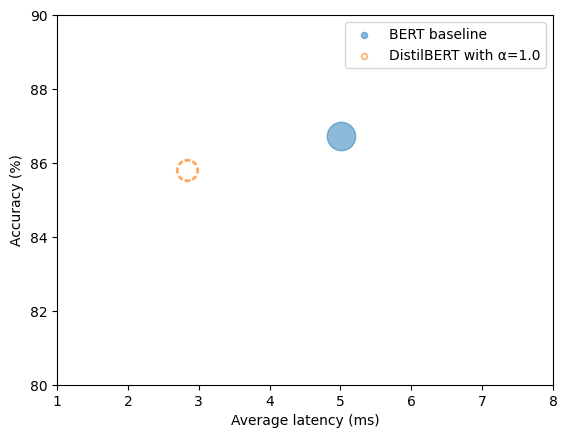

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_metrics(perf_metrics, current_optim_type):
    df = pd.DataFrame.from_dict(perf_metrics, orient='index')

    for idx in df.index:
        df_opt = df.loc[idx]
        # 현재 최적화 방법을 점선으로 그립니다
        if idx == current_optim_type:
            plt.scatter(df_opt["time_avg_ms"], df_opt["accuracy"] * 100,
                        alpha=0.5, s=df_opt["size_mb"], label=idx,
                        marker='$\u25CC$')
        else:
            plt.scatter(df_opt["time_avg_ms"], df_opt["accuracy"] * 100,
                        s=df_opt["size_mb"], label=idx, alpha=0.5)

    legend = plt.legend(bbox_to_anchor=(1,1))
    for handle in legend.legend_handles:
        handle.set_sizes([20])

    plt.ylim(80,90)
    # 가장 느린 모델을 사용해 x 축 범위를 정합니다
    xlim = int(perf_metrics["BERT baseline"]["time_avg_ms"] + 3)
    plt.xlim(1, xlim)
    plt.ylabel("Accuracy (%)")
    plt.xlabel("Average latency (ms)")
    plt.show()

plot_metrics(perf_metrics, optim_type)

4. 그래프를 보면 작은 모델을 사용해 평균 레이턴시를 크게 줄였다.
    - 정확도를 1% 감소시켜서 얻은 결과이다.

### Chapter 3-5 옵투나로 좋은 하이퍼파라미터 찾기      <a class="anchor" id="chapter3-5"></a>
1. 좋은  α와 T값을 찾기 위해 2D 하이퍼파라미터 공간에 그리드 서치를 수행한다.
    - 옵투나를 사용해 진행한다.

2. 옵투나는 검색 문제를 여러 시도를 통해 최적화할 목적 함수로 표현한다.
    - 최적화 프레임워크를 테스트하기 위한 유명한 로젠브록의 바나나 함를 최소화 한다고 가정한다.
    - Rosenbrock 함수: f(x, y) = (a - x)² + b(y - x²)², 여기서 a=1, b=100
    - 아래 그림과 같이 함수는 (x, y) = (1, 1)에서 전역 최소값을 가진다.
    - 골짜기 영역을 찾는 것은 쉬운 최적화 문제이지만 전역 최솟값으로 수렴하기는 어렵다.

        ![Rosenbrock Function](image/08-05-rosenbrock-function.png)

In [54]:
# f(x, y)의 값을 반환하는 objective()함수를 정의해 f(x, y)를 최소값을 찾는다.
def objective(trial):
    # 최적화할 하이퍼파라미터를 정의한다.
    #   - suggest_float: 균등하게 샘플링할 파라미터 범위를 지정한다.
    x = trial.suggest_float("x", -2.0, 2.0)
    y = trial.suggest_float("y", -2.0, 2.0)
    # Rosenbrock 함수를 계산한다.
    a = 1.0
    b = 100.0
    f_xy = (a - x) ** 2 + b * (y - x ** 2) ** 2
    return f_xy

In [55]:
# 옵투나는 여러 시도를 하나의 Study로 수집하므로 다음처럼 Ojbective() 함수를 study.optimize() 메서드에 전달한다.
import optuna

study = optuna.create_study()
study.optimize(objective, n_trials=1000)

[I 2026-02-07 18:59:10,945] A new study created in memory with name: no-name-2b4c5236-b66a-40e1-8ff2-dc75a34ecdd4
[I 2026-02-07 18:59:10,948] Trial 0 finished with value: 150.5537918671573 and parameters: {'x': -0.31452077282592494, 'y': 1.3188652291109495}. Best is trial 0 with value: 150.5537918671573.
[I 2026-02-07 18:59:10,949] Trial 1 finished with value: 418.8458062966707 and parameters: {'x': 1.5854066111756375, 'y': 0.46777927826890586}. Best is trial 0 with value: 150.5537918671573.
[I 2026-02-07 18:59:10,950] Trial 2 finished with value: 22.471953834716576 and parameters: {'x': -0.9980737214775686, 'y': 1.4260308487475006}. Best is trial 2 with value: 22.471953834716576.
[I 2026-02-07 18:59:10,950] Trial 3 finished with value: 177.24107227486093 and parameters: {'x': -0.798300328647044, 'y': -0.6818344276405002}. Best is trial 2 with value: 22.471953834716576.
[I 2026-02-07 18:59:10,951] Trial 4 finished with value: 76.6731624357036 and parameters: {'x': -1.5720378322554085, 

In [56]:
# 스터디가 완료되면 다음처럼 최상의 파라미터를 얻는다.
study.best_params

{'x': 0.9788430021590508, 'y': 0.9580099630450626}

3. 1,000번의 시도를 통해 옵투나는 전역 최솟값에 상당히 가까운 x, y값을 찾는다.

4. 트랜스포머스에서 옵투나를 사용하기 위해 비슷한 로직을 사용한다.
    - 최적화하려는 하이퍼파라미터 공간을 정의한다.

In [57]:
def hp_space(trial):
    return {
        "num_train_epochs": trial.suggest_int("num_train_epochs", 5, 10),
        "alpha": trial.suggest_float("alpha", 0.0, 1.0),
        "temperature": trial.suggest_int("temperature", 2, 20),
    }

In [58]:
# 트래이너의 hyperparameter_search() 메서드를 사용해 옵투나로 하이퍼파라미터 최적화를 수행한다.
best_run = distilbert_trainer.hyperparameter_search(
    direction="maximize",
    hp_space=hp_space,
    n_trials=20,
    backend="optuna",
)

[I 2026-02-07 18:59:19,889] A new study created in memory with name: no-name-ab0c50ac-a546-4c44-a1dd-06a33956b096


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.221762,0.587742
2,0.347081,0.112688,0.814839
3,0.347081,0.080360,0.864516
4,0.130896,0.067000,0.879032
5,0.092579,0.062663,0.880968


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-02-07 19:34:49,766] Trial 19 pruned. 


In [59]:
print(best_run)

BestRun(run_id='10', objective=0.9325806451612904, hyperparameters={'num_train_epochs': 10, 'alpha': 0.35111226857807437, 'temperature': 2}, run_summary=None)


In [61]:
# 훈련 매개변수를 이 값으로 바꾸고 최종훈련을 진행한다.
for k, v in best_run.hyperparameters.items():
    setattr(distilbert_trainer.args, k, v)

# 정제된 모델을 저장할 새로운 저장소 정의
distilled_ckpt = "distilbert-base-uncased-distilled-clinc"
distilbert_trainer.args.output_dir = distilled_ckpt

# 최적의 매개변수로 새로운 Trainer를 만든다.
# Trainer가 tokenizer 인자를 받지 못하는 경우 데이터 콜레이터를 명시적으로 지정하고 tokenizer는 별도 할당
data_collator = DataCollatorWithPadding(tokenizer=student_tokenizer)

# transformers 최신 버전 업데이트로 compute_loss에 추가된 인자(num_items_in_batch)를 처리하기 위한 래퍼 클래스
class DistillationTrainerWrapper(DistillationTrainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        return super().compute_loss(model, inputs, return_outputs=return_outputs)

distilbert_trainer = DistillationTrainerWrapper(
    model_init=student_init,
    teacher_model=teacher_model,
    args=student_training_args,
    train_dataset=clinc_enc["train"],
    eval_dataset=clinc_enc["validation"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)
distilbert_trainer.tokenizer = student_tokenizer

distilbert_trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.427784,0.717419
2,1.753231,0.716551,0.859355
3,1.753231,0.422839,0.910323
4,0.658623,0.316656,0.932903
5,0.319366,0.278960,0.937742
6,0.319366,0.262814,0.942258
7,0.237326,0.253346,0.943548
8,0.210898,0.249820,0.942258
9,0.210898,0.246844,0.943226
10,0.201112,0.246477,0.943226


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3180, training_loss=0.5427763525045143, metrics={'train_runtime': 135.0446, 'train_samples_per_second': 1129.257, 'train_steps_per_second': 23.548, 'total_flos': 827728372450224.0, 'train_loss': 0.5427763525045143, 'epoch': 10.0})

6. 스튜던트의 매개변수 개수는 거의 티처의 절반이지만 치저의 정확도에 버금가는 스튜던트 훈련을 할 수 있다.


In [62]:
# 허브에 업로드
distilbert_trainer.push_to_hub("Final Training Completed!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/ParkJuYeong/distilbert-base-uncased-distilled-clinc/commit/2f2eba920642ec0545955d6008674b53d27e970c', commit_message='Final Training Completed!', commit_description='', oid='2f2eba920642ec0545955d6008674b53d27e970c', pr_url=None, repo_url=RepoUrl('https://huggingface.co/ParkJuYeong/distilbert-base-uncased-distilled-clinc', endpoint='https://huggingface.co', repo_type='model', repo_id='ParkJuYeong/distilbert-base-uncased-distilled-clinc'), pr_revision=None, pr_num=None)

### Chapter 3-6 정제모델 벤치마크 수행하기       <a class="anchor" id="chapter3-6"></a>


In [63]:
distilled_ckpt = "ParkJuYeong/distilbert-base-uncased-distilled-clinc"
pip = pipeline("text-classification", model=distilled_ckpt)
optim_type = "Distillation"
pb = PerformanceBenchmark(pip, clinc["test"], optim_type=optim_type)
perf_metrics.update(pb.run_benchmark())

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/322 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

모델 크기: 255.88 MB
평균 레이턴시 (ms): 3.45 ± 2.64
정확도: 0.877


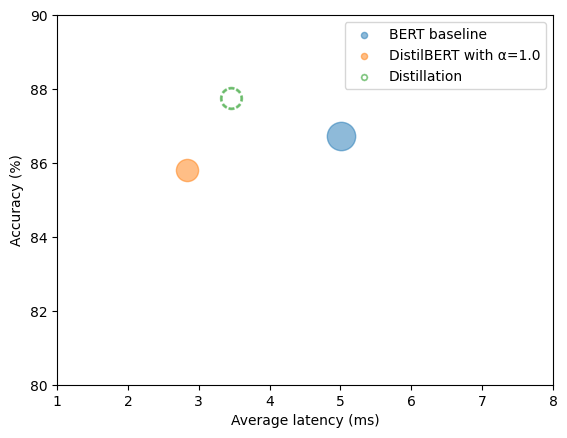

In [64]:
# plot_metrics 함수 재사용
plot_metrics(perf_metrics, optim_type)

1. 모델 크기와 레이턴시는 기본적으로 DistilBERT에 비해 크게 달라지지 않았다.
    - 정확도는 향상되었고, 티청의 성능보다 뛰어나다.

## Chapter 4. 양자화로 모델 속도 높이기       <a class="anchor" id="chapter4"></a>
1. 양자화는 계산량을 줄이는 대신, 자중치와 활성화 출력을 부동 소수점(FP32)이 아닌 8비트 정수(INT8)로 표현해 걔산을 더 효율적으로 수행한다.
    - 비트 수를 줄이면 모델에 필요한 메모리 양이 줄고, 행렬 곱셈 같은 연상이 정수 계산으로 휠씬 빠르게 수행된다.
    - 정확도 손실에 미치는 영향은 거의 없다.

2. 부동 소수점 숫자
    - 137.035 = (-1)⁰ × 1.37035 × 10²
    - 1.370035는 가수, ²는 지수, (-1)⁰은 부호이다.

3. 모델이 훈련되고 난 이후, 추론을 실행할 때는 정방향 패스만 필요하다.
    - 양자화는 주로 추론 단계에서 사용된다.
    - 훈련 단계에서는 모델이 부동 소수점 정밀도를 필요로 하기 때문에 양자화를 적용하지 않는다.

4. 신경망에서는 일반적으로 낮은 정밀도 데이터 타입을 위한 고정 소수점 포멧을 사용한다.
    - 동일 타입의 모든 변수에 대해 공통 비율로 스켈일이 조정되는 B 비트 정수로 실수를 표현한다.
    - 137.053은 1/1,000로 스케일이 조정되는 정수 137,035로 표현된다.
    - 이 스케일링 인자를 조정해서 소숫점 숫자의 범위와 정밀도를 제어한다.

5. 양자화의 기본 아이디어는 부동 소수점 숮자 f를 '이산화'하여 정수 q로 매핑하는 것이다.
    - 원래 범위 [f_min, f_max]를 정수 범위 [q_min, q_max]로 매핑한다.
    - 모든 값을 이 사이에 선형적으로 분포시킨다.
    - f = ((f_max - f_min) / (q_max - q_min)) * (q - Z) = S * (q - Z)
        - S는 양의 부동 소숫점 숫자
        - 상수 Z는 q와 타입이 동일하며 부동 소수점 값 f=0을 양자한 값에 해당하기 때문에 영점이라고 부른다.

6. 고정 소수점 숫자를 역양자홯 부동 소수점 숫자로 돌리여야 하므로 이 매핑은 아핀 변환이다.
    - 아핀 변환: 선형 변환에 평행 이동이 추가된 것
    - f = S * (q - Z)
    
        ![Affine Transformation](image/08-06-affine-transformation.png)

7. 트랜스포머가 양자화의 주요 후보인 이유는 가중치 활성화의 값 범위가 비교적 좁기 때문이다.
    - FP32 숫자의 전체 범위를 INT8로 표현되는 2⁸=256개의 값으로 매핑할 필요가 없다.

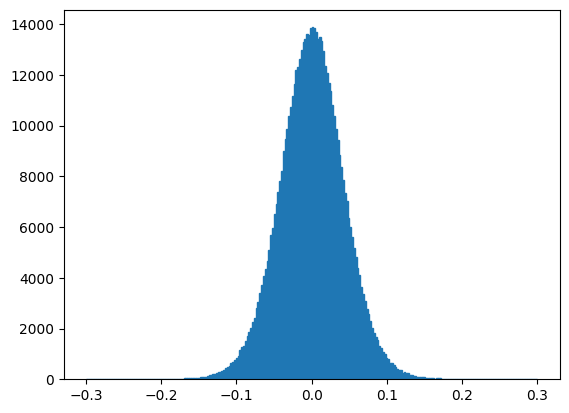

In [65]:
# 정제 모델의 어텐션 가중치 행렬 중 하나를 선택해 값의 빈도 분로를 그린다.
import matplotlib.pyplot as plt

state_dict = pip.model.state_dict()
weights = state_dict["distilbert.transformer.layer.0.attention.q_lin.weight"]
plt.hist(weights.flatten().cpu().numpy(), bins=250, range=(-0.3, 0.3), edgecolor='C0')
plt.show()

8. 가중치 값이 원점에 가깝고 범위가 좁은 [-0.1, 0.1] 사이에 분포한다.
    - 이 텐서를 부호가 있는 정수로 압축한다고 가정하면, 가능한 정수 법위는 [q_min, q_max] = [-128, 127]이다.

In [66]:
# 정수 법위는 [q_min, q_max] = [-128, 127]로 압축한다.
zero_point = 0
scale = (weights.max() - weights.min()) / (127 - (-128))

9. 양자화된 텐서를 얻으려면 매핑을 뒤집어 q = round(f / S) + Z를 적용하고, 범위 밖의 값을 클리핑하고, 가장 가까운 정수로 반올림한다.
    - Tensor.char() 함수를 사용해 torch.int8 타입으로 변환한다.

In [67]:
(weights / scale + zero_point).clamp(-128, 127).round().char()

tensor([[ -1,   5,  -4,  ...,   4,  12,   9],
        [  1,   6, -13,  ...,  -5,  29,   3],
        [ -1,   7,   4,  ...,  -2,   2,  -9],
        ...,
        [  2,   0,  15,  ...,  14,   9,  -7],
        [  1,  18,  18,  ...,  -5,  25,   3],
        [ -2, -19,   3,  ..., -10, -21,  -6]], device='cuda:0',
       dtype=torch.int8)

In [68]:
# quantize_per_tensor() 함수와 torch.qint를 사용해 동일한 양자화된 텐서를 얻는다.
from torch import quantize_per_tensor, qint8

dtype = torch.qint8
quantized_weights = quantize_per_tensor(weights, scale=scale, zero_point=zero_point, dtype=dtype)
quantized_weights.int_repr()

tensor([[ -1,   5,  -4,  ...,   4,  12,   9],
        [  1,   6, -13,  ...,  -5,  29,   3],
        [ -1,   7,   4,  ...,  -2,   2,  -9],
        ...,
        [  2,   0,  15,  ...,  14,   9,  -7],
        [  1,  18,  18,  ...,  -5,  25,   3],
        [ -2, -19,   3,  ..., -10, -21,  -6]], device='cuda:0',
       dtype=torch.int8)

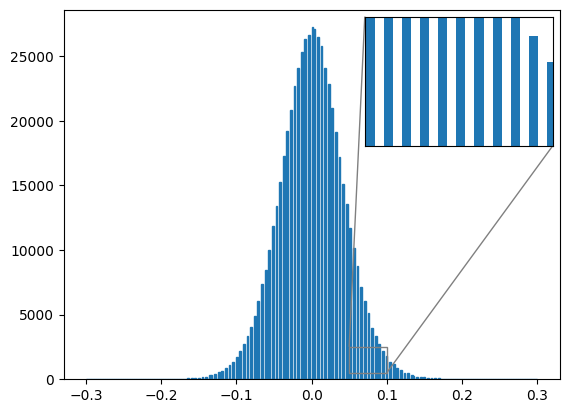

In [70]:
# 트랜스포머 가중치에서 양자화 효과
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes,mark_inset

# 히스토그램 그리기
fig, ax = plt.subplots()
ax.hist(quantized_weights.dequantize().flatten().cpu().numpy(),
         bins=250, range=(-0.3,0.3), edgecolor="C0");
# 확대 그림 만들기
axins = zoomed_inset_axes(ax, 5, loc='upper right')
axins.hist(quantized_weights.dequantize().flatten().cpu().numpy(),
         bins=250, range=(-0.3,0.3));
x1, x2, y1, y2 = 0.05, 0.1, 500, 2500
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.axes.xaxis.set_visible(False)
axins.axes.yaxis.set_visible(False)
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")
plt.show()

In [74]:
%%timeit
weights @ weights

54.5 μs ± 3.81 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [75]:
# FP32와 INT8 값의 가중치 텐서를 사용해 곱셈할 때 걸리는 시간을 비교한다.
from torch.nn.quantized import QFunctional

q_fn = QFunctional()

In [77]:
%%timeit
q_weights_cpu = quantized_weights.cpu()
q_fn.mul(q_weights_cpu, q_weights_cpu)

416 μs ± 34.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


10. 동적 양자화
    - 훈련 도중에 아무것도 바뀌지 않고 추론 과정에만 정용된다.
    - 모델 가중치가 추론 전에 INT8로 변환된다.
    - 모델의 활성화가 즉석에서 일어나기 때문에 동적인 방식이다.
    - 부동 소수점 포멧으로 화성화 메모리를 쓰고 읽기 때문에 정수와 부동소수점 간의 변황이 성능 병목이 되는 경우가 있다.

11. 정적 양자화
    - 양자화 체계를 사전에 계산해 부동 소수점 변환을 피한다.
    - 활성화 패턴을 관찰해 이를 수행하고, 이상적인 양자화 체계를 계산해 저장한다.
    - INT8과 FP32 간의 전환을 피하고 계산 속도를 높일 수 있다.
    - 좋은 데이터 샘플을 찾아야하고 파이프라인에 추가 단계를 도입해야한다.
    - 훈련과 추론 과정에서 정밀도의 차이로 모델성능이 떨어진다.

12. 양자화를 고려한 훈련
    - 가짜로 F32 값을 양자화해 훈련 중에 양자화의 효과를 시뮬레이션 한다.
    - INT8을 사용하는 대신 F32를 반올림해 양자화 효과를 흉내낸다.
    - 정방향 패스와 역방행 패스 모두에 적용되면 정적 양자화와 동적 양자화를 사용해 모델 선능을 향상한다.

13. 트랜스포머로 추론을 실행할 때 주요 병목지점은 많은 개수의 모델 가중치에 연관된 계산과 메이로 대역폭이다.
    - 현재 NLP에서 동적 양자화는 트랜스포머 기반 모델에 대한 최상의 선택이다.
    - 작은 컴퓨터 비전 모델에서는 활성화에 대한 메모리 대역폭 제약때문에 정적 양자화가 더 나을 수 있다.


In [82]:
from torch.quantization import  quantize_dynamic

model_ckpt = "ParkJuYeong/distilbert-base-uncased-distilled-clinc"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt).to("cpu")

model_quantized = quantize_dynamic(
    model, {torch.nn.Linear}, dtype=torch.qint8
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

/tmp/ipykernel_9365/4210207591.py:7: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_quantized = quantize_dynamic(


## Chapter 5. 양자화된 모델 벤치마크 수행하기       <a class="anchor" id="chapter5"></a>

In [83]:
model_quantized = model_quantized.to("cpu")
pip = pipeline("text-classification", model=model_quantized, tokenizer=tokenizer, device=-1)
optim_type = "Distillation + Quantized"
pb = PerformanceBenchmark(pip, clinc["test"], optim_type=optim_type)
perf_metrics.update(pb.run_benchmark()) 

모델 크기: 132.39 MB
평균 레이턴시 (ms): 2.90 ± 0.63
정확도: 0.890


In [ ]:
plot_metrics(perf_metrics, optim_type)